# Log Book for Work on Seasonal Metrics
This is a log book intended for notes as I continue the work on the seasonal metrics. I haven't been doing a good job taking notes on my process and it is time to start this up!

## Date: 2026-09-10

Today I 
- Met with Sanchia and got her started looking for interior temperature regulations for Canada, building energy data
- Created a script for CMIP6 winter stats based on the CMIP6 summer script. Test ran for a few years with the GFDL-ESM4 data over 1990-2024 (uses ssp2-4.5 for 2015-2024)
- Started this log!

TODOs that I thought of today:
1. run the winter script for all the CMIP6 data so far
2. also update the WinterSummerDay script for the CMIP6 data
3. also update the SpringAndAutumn and AnalyzeTrendsWinter scripts to use CMIP6 data
4. still need to do winters from GHCND
5. still need to download more CMIP6 data - Marysa offered to teach me about GLOBUS and pulling from EGSF but I kinda like using the Copernicus download. However I need to use Sockeye at some point here...

## Date: 2026-09-11

Today I:
- Processed all the Winter stats for the CMIP6 models I have so far, which is CESM2 & GFDL-ESM4 (1990-2023) which uses SSP2-4.5 data for 2015-2024, and CanESM5 (1990-2099) which uses SSP2-4.5 data for 2015-2100 (item #1 above DONE)
- Downloaded and fixed the lon coords for the landsea masks for CESM2, GFDL-ESM4, and CanESM5

TODOs that I thought of today:
1. Should analyze the CanESM5 winter data and include the LSM so I can filter for land, then run the SpringAndAutumn script to include these data to see how visuals look with the additional years *** Do before lab meeting on Thursday ***


## Date: 2026-09-16

Today I:
- Finished processing all seasons over 1990-2100 from CanESM5 SSP2-4.5 to see how it looks. It is clear that zero-length winters are going to need some thinking to adjust the visuals to make sense. Lots of negative season lengths because of how the math workes out. Maybe can ensure that no season overlaps by using the boundaries of the neighboring seasons as limits?
- prepared a presentation for the CCEL lab meeting to show off recent results


TODOs that I thought of today:
- be more systematic about each new piece of work. Maybe should make a to-do list that I check off because I forget (e.g.) that I have already run the winter gradient script.
- should run the other two model outputs for seasons - GFDL-ESM4 and CESM2 to see if the winter length of zero is a common problem



## Date: 2026-09-17

Today I:
- Presented some of the visual ideas in group meeting. General consensus was the circular anomaly plot has impact but could be hard ot interpret by non-sci-literate audience
- anomaly dot plot works well too
- Have to deal with zero-length winters in a robust way


TODOs that I thought of today:
- Zero-length winter: can find the midpoint of the "dip" where winter would be and call that where autumn ends and spring begins? this would then override the other season length calculations whenever winterlength == 0. Need to think of an algorithm to identify this location.
- (chatted with Simon) Can use a 15 or 29-day smoothing to take care of the "ripples" in the Fourier fit and find the lowest point to call that the center of the "winter". Simon says to use odd number of days. So, I will need to reprocess all the data for winters and record this for everywhere? Or can I only pay the cost of the smoothing if winter length already comes out to zero. I think I can do the latter...
- Simon says I should test a few smoothing windows to show that the midpoint location is fairly insensitive to the smoothing window, so I can test this first. Vancouver 2005 winter is a good test case since it has length zero and has a couple of ripples



## Date: 2026-09-18

Today I:
- Used smoothing to iron out ripples and identify the lowest point in the T2m time series to call the point of winter that divides Autumn from Spring when winter length == 0 (Fourier fit does not go below 25th percentile temp from baseline period
- Validated that the window size N for smoothing over 15 - 45 days does not impact the location of the lowest point vs Fourier fit (but the lowest point in the smoothed curve required an added offset of N/2 because smoothing loses fidelity). I tested 2005 with zero length winter for Vancouver and found each window yielded a minimum around 200, ranging from day 198 to 208.
- Selected 29 d window to use as default for next phase of processing
- Now running updated Processing for winters from CanESM5 and will do same for other CMIP6 models so far AND for ERA5 which will take a while.

TODOs that I thought of today:
- obviously will need to re-run all of the SpringAndAutumn... script AND the AnalyzeTrends... scripts AND the StartEndGradient too



## Date: 2026-09-22

Today I:
- Updated the Process...Winter scripts to smooth over 91 days instead of 29 once I tested a few more years for Vancouver - if they had multiple ripples but stayed above the threshold it was not finding the right smoothed minimum. I tested 2002, 2005, 2025 and windows from 29 to 91 (29/31/45/61/75/91) and found that the longer period was needed to smooth out the ripples in the Fourier fit and keep a consistent minimum (e.g. 2025 ranged from 196 - 210). A few examples are shown in the script ProcessMultipleYearsFourierWinters.
- Started re-running all ERA5 winters and also CanESM5

TODOs that I thought of today:
- Winter Gradient script may need adjustment and re-running now that start/end logic is different. That script currently doesn't do the additional smoothing to handle zero length winters and should output gradients of zero for those winters. Need to check. ** nevermind, I already handled them by outputting np.nan for the gradients of zero length winters, which seems like a good solution too.
- Need to run other CMIP6 models for winters and then start on NorESM which I just downloaded from Copernicus
- With four models, can try to create the Taylor Diagram script based on these sites: https://k-diagram.readthedocs.io/en/latest/user_guide/taylor_diagram.html https://climatedataguide.ucar.edu/climate-tools/taylor-diagrams and original paper https://agupubs.onlinelibrary.wiley.com/doi/epdf/10.1029/2000JD900719
- Also, need to reorganize folder structure for the CMIP6 models to be consistent on historical vs SSPs
- and fix the coords of the newest data downloaded (Nor-ESM2-MM historical and CanESM5 SSP1-1.9)


## Date: 2026-09-24

Today I:
- Ran the baseline calculation script for NorESM2-MM (1961-1990), but something is funny with google drive because sometimes files are not saving - need to look into that more
- NorESM2 has a weird grid for the seamask file I got from Copernicus. going to need to find another?
- Met with Rachel and these things came up to look into
- - The CanESM5 projections for SSP2-4.5 show winter going away over ocean and autumn growing while spring goes away. This implies a signifiant shape change to the timeseries. Need to see if this same effect happens with other climate model output. If it does, she suggests I do a 30 year period climatology vs a later 30 yr one and subtract the timeseries to see if there's a real change. And do same for other model projections.
  - To do Taylor diagrams to compare models with ERA5 they all need to be on the same grid. So, I should rerun summer/winter/seasons with the 1$^{\circ}$ resolution ERA5 and then use 1$^{\circ}$ climate models and compare via Taylor diagram. This will help select which models to use.
  - For the finer resolution study (e.g. Cities like Paris, and Canada) I can then use the 0.25$^{\circ}$ ERA5 results I have and the NASA downscaled 0.25$^{\circ}$ projections for comparison.
  - So, lots more data to download and analyze! :(

TODOs that I thought of today:
- 


## Date: 2026-09-28

Today I:
- Rachel and i went back and forth about regridding and the resolution of the data sets. She has solid concerns about making sure the grids match when looking at the higher resolution NASA data vs 0.25 deg ERA5 ("Strictly speaking, you should make sure that the NASA downscaled dataset is on the same 0.25 deg grid as ERA5, and if it isn't, interpolate onto the ERA5 grid before you start analysis")
- Sounds like to avoid regridding I will need to run the analysis on 1 deg ERA5 to compare to 1 deg CMIP6 models to get the global metrics
- For the city/regional level results, I will need to use ERA5 0.25 deg metrics and compare with the NASA GEX metrics from the downscaled CMIP6 models
- Also worth noting that for the 1 deg data I also need the landsea mask for both ERA5 and any of the CMIP6 models
- For Taylor diagrams to select models, I can compare the summer and winter length, and the gradients, to capture the "shape" of the time series and see which models are 'best'
- Alternatively, I just use every CMIP6 model on a 1 deg grid and a 365 day year?
- Maybe I should re-grid? If so, confirm method of regridding. 

TODOs that I thought of today:
- Need to ask Rachel what she means by the "interpolate onto the ERA5 grid" comment
- Will need to start over with 1 deg ERA5 and run all metrics for summer/winter/seasons/trends/gradients to compare with CMIP6


## Date: 2026-09-29

Today I:
- Updated script for CDSAPI and started pulling ERA5 at $1^{\circ}$ which can be done by setting a parameter (CDS does the regridding)
- Finished the Winter Length and Cold script for ERA5 $0.25^{\circ}$ by doing the LOWESS and PWLF acceleration checks. Looks like Winter Length has accelerated since ~2010 esp in NH

TODOs that I thought of today:
- Will need to compare trends from $0.25^{\circ}$ ERA5 and $1^{\circ}$ ERA5 to understand effect of regridding
- Read up on how CDS does the regridding (what method do they use) - got the answer: "interpolation method is bilinear for continuous parameters (e.g. Temperature)" from https://confluence.ecmwf.int/spaces/CKB/pages/65237704/ERA5+What+is+the+spatial+reference
- I should edit and run the rest of the Winter gradient script! The yearly data files are calculated but not the maps and trends. 


## Date: 2026-10-02

Today I:
- Stopped pulling 1 deg ERA5! We discussed it and I won't be needing it. Instead, I will use the NASA NEX-GDDP datasets for the global and regional/city level seasonal paper. I can compare to my existing ERA5 0.25 deg results.
- Downside: it is land only, and also limited to -60 to 90 Latitude N so there will not be as much SH land in the analysis. No ocean results in this paper. Simon and I discussed doing a separate paper on ocean seasons or maybe a future student can work on it.
- NEX-GDDP and ERA5 are both 0.25$^{\circ}$ but not the same grid range (NEX-GDDP native runs array([-59.875, -59.625, -59.375, ...,  89.375,  89.625,  89.875], shape=(600,)) while ERA5 runs array([-90.  , -89.75, -89.5 , ...,  89.5 ,  89.75,  90.  ], shape=(721,)).
- Can use CDO to match them up. Initially tried regridding a test file of ERA5 (first used 'cdo mergetime' to combine 12 months into one year! why have I not done this before?) for the year of 1961 to the 1961 NEX-GDDP CESM2 data (tas_day_CESM2_historical_r4i1p1f1_gn_1961_v2.0.nc) but got an error 'Operator cannot be assigned'.
- I did not find good examples online of this error, but I suspect it was related to the different grid ranges. Thankfully, from this post (https://code.mpimet.mpg.de/boards/1/topics/8586), I did learn that I can remap the NEX-GDDP files to a full 1440x721 grid (full global area same as ERA5):
  - using 'cdo remapbil,r1440x721 tas_day_CESM2_historical_r4i1p1f1_gn_1961_v2.0.nc tas_CESM2_historical_1961_1440x721.nc'. A downside is that the file size goes from 244mb to 1.5gb.
- and then I just need to set the longitude to run from -180 to 180:
  - using cdo 'cdo -sellonlatbox,-180,180,-90,90 tas_CESM2_historical_1961_1440x721.nc tas_CESM2_historical_1961_1440x721_-180_180.nc'
I inspected the outputs in a Jupyter notebook and things look good. ERA5 has ocean, obviously, but a diff of the tas values from Jan 1 1961 looks like

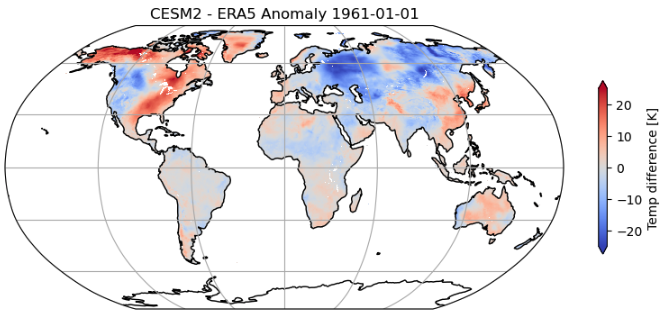

So, I will need to downoad more NEX-GDDP data and do both cdo changes to them, in addition to the variable naming change from tas to t2m or vice versa

TODOs that I thought of today:
- Can I do the update of the time variable to a datetimeindex using CDO or do I have to do that in python? [ds_cesm2['time'] = ds_cesm2.indexes['time'].to_datetimeindex()]


## Date: 

Today I:
- 

TODOs that I thought of today:
- 


## Date: 

Today I:
- 

TODOs that I thought of today:
- 


## Date: 

Today I:
- 

TODOs that I thought of today:
- 


## Date: 

Today I:
- 

TODOs that I thought of today:
- 


## Date: 

Today I:
- 

TODOs that I thought of today:
- 
